<a href="https://colab.research.google.com/github/shyamsundarsah123/machine-learning/blob/main/Copy_of_Lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from scipy.spatial.distance import minkowski as scipy_minkowski
from google.colab import drive

drive.mount('/content/drive')
DATA_FILE = "/content/drive/MyDrive/ML_lab/Lab Session Data.xlsx"
SHEET_NAME = "marketing_campaign"

print("Common setup completed successfully.")

# GenAI Tool Used: ChatGPT


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Common setup completed successfully.


In [ ]:
# GenAI Tool Used: ChatGPT

def load_dataset(file_path):
    return pd.read_excel(
        file_path,
        sheet_name=SHEET_NAME
    )


def identify_feature_types(dataframe):

    feature_information = []

    for column in dataframe.columns:

        dtype = dataframe[column].dtype

        if dtype == "object":
            datatype = "Nominal"

        elif "date" in column.lower():
            datatype = "Interval"

        elif dataframe[column].nunique() < 15:
            datatype = "Ordinal"

        else:
            datatype = "Ratio"

        feature_information.append({
            "Feature": column,
            "Python Datatype": str(dtype),
            "Measurement Type": datatype
        })

    return pd.DataFrame(feature_information)

In [ ]:
# GenAI Tool Used: ChatGPT
# A1 - LOAD DATASET AND FEATURE TYPE IDENTIFICATION

def load_dataset(file_path):

    return pd.read_excel(
        file_path,
        sheet_name=SHEET_NAME
    )


def identify_feature_types(dataframe):

    feature_information = []

    for column in dataframe.columns:

        dtype = dataframe[column].dtype

        if dtype == "object":
            datatype = "Nominal"

        elif "date" in column.lower():
            datatype = "Interval"

        elif dataframe[column].nunique() < 15:
            datatype = "Ordinal"

        else:
            datatype = "Ratio"

        feature_information.append({
            "Feature": column,
            "Python Datatype": str(dtype),
            "Measurement Type": datatype
        })

    return pd.DataFrame(feature_information)


# A2 - LABEL ENCODING

def label_encode_column(series):

    unique_values = list(
        series.dropna().unique()
    )

    mapping = {}

    for index, value in enumerate(unique_values):
        mapping[value] = index

    encoded = []

    for item in series:

        if pd.isna(item):
            encoded.append(np.nan)

        else:
            encoded.append(
                mapping[item]
            )

    return encoded, mapping


def perform_label_encoding(dataframe):
    encoded_dataframe = dataframe.copy()

    mappings = {}

    categorical_columns = dataframe.select_dtypes(
        include=["object"]
    ).columns

    for column in categorical_columns:

        encoded_values, mapping = label_encode_column(
            dataframe[column]
        )

        encoded_dataframe[column] = encoded_values

        mappings[column] = mapping

    return encoded_dataframe, mappings


# A3 - ONE-HOT ENCODING

def one_hot_encode_column(dataframe, column_name):

    dataframe = dataframe.copy()

    unique_values = (
        dataframe[column_name]
        .dropna()
        .unique()
    )

    encoded_columns = {}

    for value in unique_values:

        new_column = f"{column_name}_{value}"

        encoded_columns[new_column] = (
            dataframe[column_name] == value
        ).astype(int)

    encoded_dataframe = pd.concat(
        [
            dataframe.drop(columns=[column_name]),
            pd.DataFrame(
                encoded_columns,
                index=dataframe.index
            )
        ],
        axis=1
    )

    return encoded_dataframe


def perform_one_hot_encoding(dataframe):

    encoded_dataframe = dataframe.copy()

    categorical_columns = (
        dataframe
        .select_dtypes(include=["object"])
        .columns
        .tolist()
    )

    for column in categorical_columns:

        encoded_dataframe = one_hot_encode_column(
            encoded_dataframe,
            column
        )

    return encoded_dataframe


def compare_feature_dimensions(
        original_dataframe,
        label_dataframe,
        onehot_dataframe):

    return pd.DataFrame({

        "Dataset": [
            "Original Dataset",
            "Label Encoded Dataset",
            "One-Hot Encoded Dataset"
        ],

        "Rows": [
            original_dataframe.shape[0],
            label_dataframe.shape[0],
            onehot_dataframe.shape[0]
        ],

        "Columns": [
            original_dataframe.shape[1],
            label_dataframe.shape[1],
            onehot_dataframe.shape[1]
        ]
    })


# A4-A6 - MINKOWSKI DISTANCE

def calculate_minkowski_distance(
        vector_a,
        vector_b,
        p):

    vector_a = np.asarray(
        vector_a,
        dtype=float
    )

    vector_b = np.asarray(
        vector_b,
        dtype=float
    )

    return np.sum(
        np.abs(vector_a - vector_b) ** p
    ) ** (1 / p)


def calculate_distance_for_orders(
        vector_a,
        vector_b,
        max_p=10):

    results = []

    for p in range(1, max_p + 1):

        distance = calculate_minkowski_distance(
            vector_a,
            vector_b,
            p
        )

        results.append({
            "p": p,
            "Minkowski Distance": distance
        })

    return pd.DataFrame(results)


def compare_with_scipy(
        vector_a,
        vector_b,
        p_values):

    results = []

    for p in p_values:

        own_distance = calculate_minkowski_distance(
            vector_a,
            vector_b,
            p
        )

        scipy_distance = scipy_minkowski(
            vector_a,
            vector_b,
            p
        )

        results.append({
            "p": p,
            "Own Implementation": own_distance,
            "SciPy": scipy_distance,
            "Difference": abs(
                own_distance - scipy_distance
            )
        })

    return pd.DataFrame(results)


# A7 - VECTOR OPERATIONS

def calculate_dot_product(
        vector_a,
        vector_b):

    vector_a = np.asarray(
        vector_a,
        dtype=float
    )

    vector_b = np.asarray(
        vector_b,
        dtype=float
    )

    result = 0

    for index in range(len(vector_a)):

        result += (
            vector_a[index]
            * vector_b[index]
        )

    return result


def calculate_euclidean_norm(vector):

    vector = np.asarray(
        vector,
        dtype=float
    )

    squared_sum = 0

    for value in vector:

        squared_sum += value ** 2

    return np.sqrt(squared_sum)


# A8-A9 - STATISTICAL ANALYSIS

def calculate_mean(values):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        ~np.isnan(values)
    ]

    if len(values) == 0:
        return np.nan

    return np.sum(values) / len(values)


def calculate_variance(values):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        ~np.isnan(values)
    ]

    if len(values) == 0:
        return np.nan

    mean = calculate_mean(values)

    return np.sum(
        (values - mean) ** 2
    ) / len(values)


def calculate_standard_deviation(values):

    variance = calculate_variance(values)

    if np.isnan(variance):
        return np.nan

    return np.sqrt(variance)


def calculate_statistics(dataframe):

    results = []

    numerical_columns = (
        dataframe
        .select_dtypes(include=[np.number])
        .columns
    )

    for column in numerical_columns:

        values = dataframe[column].to_numpy(
            dtype=float
        )

        results.append({

            "Feature": column,

            "Own Mean":
                calculate_mean(values),

            "NumPy Mean":
                np.nanmean(values),

            "Own Std Dev":
                calculate_standard_deviation(values),

            "NumPy Std Dev":
                np.nanstd(values)
        })

    return pd.DataFrame(results)


# A10 - HISTOGRAM

def plot_histogram(
        dataframe,
        column_name,
        bins=30):


    values = dataframe[column_name].dropna()

    plt.figure(figsize=(8, 5))

    plt.hist(
        values,
        bins=bins
    )

    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.title(
        f"Histogram of {column_name}"
    )

    plt.tight_layout()
    plt.show()


# A11 - K-MEANS CLUSTERING

def calculate_euclidean_distance(
        vector_a,
        vector_b):

    vector_a = np.asarray(
        vector_a,
        dtype=float
    )

    vector_b = np.asarray(
        vector_b,
        dtype=float
    )

    return np.sqrt(
        np.sum(
            (vector_a - vector_b) ** 2
        )
    )


def initialize_centroids(data, k):

    indices = np.random.choice(
        len(data),
        size=k,
        replace=False
    )

    return data[indices].copy()


def assign_clusters(data, centroids):

    labels = []

    for point in data:

        distances = []

        for centroid in centroids:

            distance = calculate_euclidean_distance(
                point,
                centroid
            )

            distances.append(distance)

        labels.append(
            np.argmin(distances)
        )

    return np.array(labels)


def update_centroids(
        data,
        labels,
        k,
        old_centroids):

    new_centroids = []

    for cluster_index in range(k):

        cluster_points = data[
            labels == cluster_index
        ]

        if len(cluster_points) == 0:

            new_centroids.append(
                old_centroids[cluster_index]
            )

        else:

            new_centroids.append(
                np.mean(
                    cluster_points,
                    axis=0
                )
            )

    return np.array(new_centroids)


def kmeans(
        data,
        k=3,
        max_iterations=100,
        tolerance=1e-4,
        random_state=42):

    np.random.seed(random_state)

    data = np.asarray(
        data,
        dtype=float
    )

    centroids = initialize_centroids(
        data,
        k
    )

    for iteration in range(
        max_iterations
    ):

        labels = assign_clusters(
            data,
            centroids
        )

        new_centroids = update_centroids(
            data,
            labels,
            k,
            centroids
        )

        centroid_shift = np.max(
            np.abs(
                new_centroids - centroids
            )
        )

        centroids = new_centroids

        if centroid_shift < tolerance:
            break

    return (
        labels,
        centroids,
        iteration + 1
    )


# STANDARDIZE DATA FOR K-MEANS

def standardize_data(dataframe):

    numerical_data = dataframe.select_dtypes(
        include=[np.number]
    ).dropna()

    data = numerical_data.to_numpy(
        dtype=float
    )

    mean = np.mean(
        data,
        axis=0
    )

    std = np.std(
        data,
        axis=0
    )

    std[std == 0] = 1

    standardized = (
        data - mean
    ) / std

    return numerical_data, standardized

LAB ASSIGNMENT 04 - A1
REPEAT OF LAB 03 USING AI TOOL

Dataset Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



A1 - FEATURE TYPE IDENTIFICATION


,Feature,Python Datatype,Measurement Type
0,ID,int64,Ratio
1,Year_Birth,int64,Ratio
2,Education,object,Nominal
3,Marital_Status,object,Nominal
4,Income,float64,Ratio
5,Kidhome,int64,Ordinal
6,Teenhome,int64,Ordinal
7,Dt_Customer,object,Nominal
8,Recency,int64,Ratio
9,MntWines,int64,Ratio



A2 - LABEL ENCODING
Original Shape: (2240, 29)
Label Encoded Shape: (2240, 29)

Label Encoding Mappings:

Education:
{'Graduation': 0, 'PhD': 1, 'Master': 2, 'Basic': 3, '2n Cycle': 4}

Marital_Status:
{'Single': 0, 'Together': 1, 'Married': 2, 'Divorced': 3, 'Widow': 4, 'Alone': 5, 'Absurd': 6, 'YOLO': 7}

Dt_Customer:
{datetime.datetime(2012, 4, 9, 0, 0): 0, datetime.datetime(2014, 8, 3, 0, 0): 1, '21-08-2013': 2, datetime.datetime(2014, 10, 2, 0, 0): 3, '19-01-2014': 4, datetime.datetime(2013, 9, 9, 0, 0): 5, '13-11-2012': 6, datetime.datetime(2013, 8, 5, 0, 0): 7, datetime.datetime(2013, 6, 6, 0, 0): 8, '13-03-2014': 9, '15-11-2013': 10, datetime.datetime(2012, 10, 10, 0, 0): 11, '24-11-2012': 12, '24-12-2012': 13, '31-08-2012': 14, '28-03-2013': 15, datetime.datetime(2012, 3, 11, 0, 0): 16, datetime.datetime(2012, 8, 8, 0, 0): 17, datetime.datetime(2013, 6, 1, 0, 0): 18, '23-12-2012': 19, datetime.datetime(2014, 11, 1, 0, 0): 20, '18-03-2013': 21, datetime.datetime(2013, 2, 1, 0,

,Dataset,Rows,Columns
0,Original Dataset,2240,29
1,Label Encoded Dataset,2240,29
2,One-Hot Encoded Dataset,2240,702



A4 - MINKOWSKI DISTANCE
Vector A: [1 2 3 4 5]
Vector B: [5 4 3 2 1]

Manhattan Distance (p=1): 12.0
Euclidean Distance (p=2): 6.324555320336759

A5 - MINKOWSKI DISTANCE FOR p = 1 TO 10


,p,Minkowski Distance
0,1,12.000000
1,2,6.324555
2,3,5.241483
3,4,4.829473
4,5,4.623158
5,6,4.501465
6,7,4.421271
7,8,4.364157
8,9,4.321176
9,10,4.287512


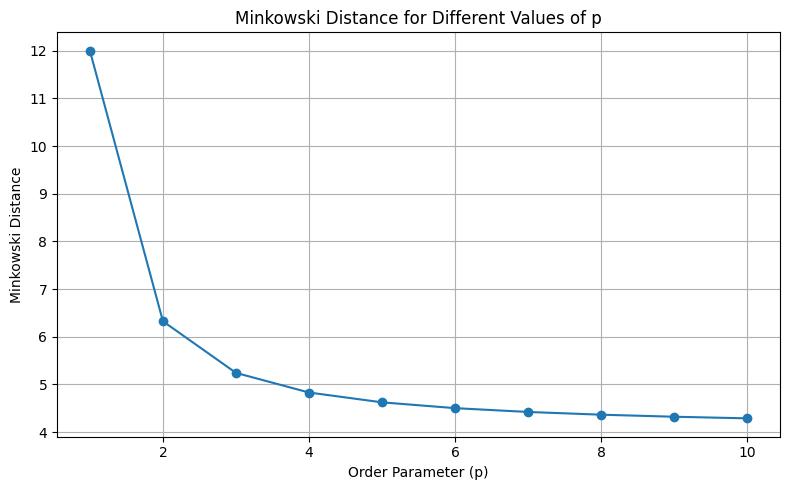


A6 - CUSTOM MINKOWSKI VS SCIPY


,p,Own Implementation,SciPy,Difference
0,1,12.000000,12.000000,0.0
1,2,6.324555,6.324555,0.0
2,3,5.241483,5.241483,0.0
3,4,4.829473,4.829473,0.0
4,5,4.623158,4.623158,0.0
5,6,4.501465,4.501465,0.0
6,7,4.421271,4.421271,0.0
7,8,4.364157,4.364157,0.0
8,9,4.321176,4.321176,0.0
9,10,4.287512,4.287512,0.0



A7 - VECTOR OPERATIONS
Own Dot Product: 35.0
NumPy Dot Product: 35

Own Euclidean Norm: 7.416198487095663
NumPy Euclidean Norm: 7.416198487095663

A8 - STATISTICAL ANALYSIS


,Feature,Own Mean,NumPy Mean,Own Std Dev,NumPy Std Dev
0,ID,5592.159821,5592.159821,3245.937415,3245.937415
1,Year_Birth,1968.805804,1968.805804,11.981394,11.981394
2,Income,52247.251354,52247.251354,25167.396174,25167.396174
3,Kidhome,0.444196,0.444196,0.538278,0.538278
4,Teenhome,0.506250,0.506250,0.544417,0.544417
5,Recency,49.109375,49.109375,28.955987,28.955987
6,MntWines,303.935714,303.935714,336.522251,336.522251
7,MntFruits,26.302232,26.302232,39.764555,39.764555
8,MntMeatProducts,166.950000,166.950000,225.664984,225.664984
9,MntFishProducts,37.525446,37.525446,54.616784,54.616784



A9 - CUSTOM STATISTICS VS NUMPY


,Feature,Own Mean,NumPy Mean,Own Std Dev,NumPy Std Dev,Mean Difference,Std Dev Difference
0,ID,5592.159821,5592.159821,3245.937415,3245.937415,0.0,0.0
1,Year_Birth,1968.805804,1968.805804,11.981394,11.981394,0.0,0.0
2,Income,52247.251354,52247.251354,25167.396174,25167.396174,0.0,0.0
3,Kidhome,0.444196,0.444196,0.538278,0.538278,0.0,0.0
4,Teenhome,0.506250,0.506250,0.544417,0.544417,0.0,0.0
5,Recency,49.109375,49.109375,28.955987,28.955987,0.0,0.0
6,MntWines,303.935714,303.935714,336.522251,336.522251,0.0,0.0
7,MntFruits,26.302232,26.302232,39.764555,39.764555,0.0,0.0
8,MntMeatProducts,166.950000,166.950000,225.664984,225.664984,0.0,0.0
9,MntFishProducts,37.525446,37.525446,54.616784,54.616784,0.0,0.0



A10 - HISTOGRAM OF INCOME


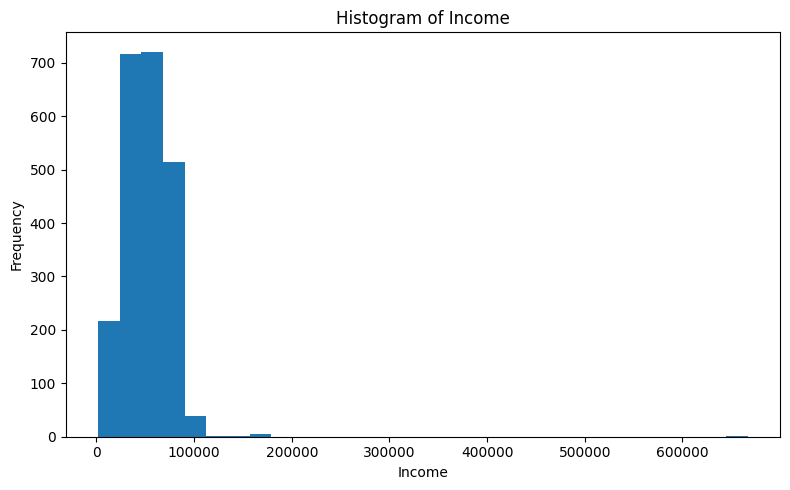


A11 - K-MEANS CLUSTERING
Number of Iterations: 21

Cluster Distribution:


,Number of Samples
0,547
1,1026
2,643



Final Cluster Centroids:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0.040537,-0.015067,1.017130,-0.744706,-0.663515,0.012386,0.918722,1.067542,1.343360,1.150808,...,-1.052131,0.033369,0.206139,0.793685,0.656542,0.183425,-0.060073,0.0,0.0,0.428735
1,0.017249,0.242409,-0.692168,0.676785,-0.113858,0.015021,-0.779466,-0.537743,-0.640233,-0.559964,...,0.481805,0.005718,-0.252920,-0.280839,-0.257682,-0.100280,0.032967,0.0,0.0,-0.153229
2,-0.062008,-0.373981,0.239182,-0.446388,0.746129,-0.034505,0.462194,-0.050112,-0.121211,-0.085489,...,0.126258,-0.037512,0.228208,-0.227068,-0.147352,0.003972,-0.001499,0.0,0.0,-0.120226


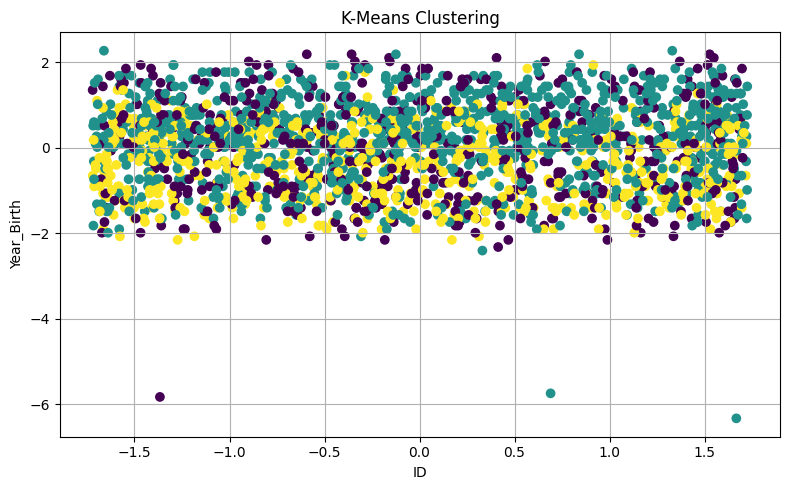

In [ ]:
# GenAI Tool Used: ChatGPT
dataset = load_dataset(DATA_FILE)

print("=" * 70)
print("LAB ASSIGNMENT 04 - A1")
print("REPEAT OF LAB 03 USING AI TOOL")
print("=" * 70)

print("\nDataset Shape:", dataset.shape)

display(dataset.head())


# A1 - FEATURE TYPE IDENTIFICATION

print("\n" + "=" * 70)
print("A1 - FEATURE TYPE IDENTIFICATION")
print("=" * 70)

feature_types = identify_feature_types(dataset)

display(feature_types)


# A2 - LABEL ENCODING

print("\n" + "=" * 70)
print("A2 - LABEL ENCODING")
print("=" * 70)

label_encoded_data, label_mappings = perform_label_encoding(
    dataset
)

print("Original Shape:",
      dataset.shape)

print("Label Encoded Shape:",
      label_encoded_data.shape)

print("\nLabel Encoding Mappings:")

for column, mapping in label_mappings.items():

    print(f"\n{column}:")
    print(mapping)


# A3 - ONE-HOT ENCODING

print("\n" + "=" * 70)
print("A3 - ONE-HOT ENCODING")
print("=" * 70)

onehot_encoded_data = perform_one_hot_encoding(
    dataset
)

print("One-Hot Encoded Shape:",
      onehot_encoded_data.shape)

dimension_comparison = compare_feature_dimensions(
    dataset,
    label_encoded_data,
    onehot_encoded_data
)

print("\nFeature Dimensionality Comparison:")

display(dimension_comparison)


# A4 - MINKOWSKI DISTANCE

print("\n" + "=" * 70)
print("A4 - MINKOWSKI DISTANCE")
print("=" * 70)

vector_a = np.array([
    1, 2, 3, 4, 5
])

vector_b = np.array([
    5, 4, 3, 2, 1
])

manhattan_distance = calculate_minkowski_distance(
    vector_a,
    vector_b,
    p=1
)

euclidean_distance = calculate_minkowski_distance(
    vector_a,
    vector_b,
    p=2
)

print("Vector A:", vector_a)
print("Vector B:", vector_b)

print("\nManhattan Distance (p=1):",
      manhattan_distance)

print("Euclidean Distance (p=2):",
      euclidean_distance)


# A5 - MINKOWSKI DISTANCE FOR DIFFERENT p

print("\n" + "=" * 70)
print("A5 - MINKOWSKI DISTANCE FOR p = 1 TO 10")
print("=" * 70)

distance_results = calculate_distance_for_orders(
    vector_a,
    vector_b,
    max_p=10
)

display(distance_results)


# MINKOWSKI DISTANCE PLOT

plt.figure(figsize=(8, 5))

plt.plot(
    distance_results["p"],
    distance_results["Minkowski Distance"],
    marker="o"
)

plt.xlabel("Order Parameter (p)")
plt.ylabel("Minkowski Distance")
plt.title(
    "Minkowski Distance for Different Values of p"
)

plt.grid(True)
plt.tight_layout()
plt.show()


# A6 - COMPARISON WITH SCIPY

print("\n" + "=" * 70)
print("A6 - CUSTOM MINKOWSKI VS SCIPY")
print("=" * 70)

scipy_comparison = compare_with_scipy(
    vector_a,
    vector_b,
    range(1, 11)
)

display(scipy_comparison)


# A7 - VECTOR OPERATIONS

print("\n" + "=" * 70)
print("A7 - VECTOR OPERATIONS")
print("=" * 70)

own_dot_product = calculate_dot_product(
    vector_a,
    vector_b
)

numpy_dot_product = np.dot(
    vector_a,
    vector_b
)

own_norm = calculate_euclidean_norm(
    vector_a
)

numpy_norm = np.linalg.norm(
    vector_a
)

print("Own Dot Product:",
      own_dot_product)

print("NumPy Dot Product:",
      numpy_dot_product)

print("\nOwn Euclidean Norm:",
      own_norm)

print("NumPy Euclidean Norm:",
      numpy_norm)


# A8 - STATISTICAL ANALYSIS

print("\n" + "=" * 70)
print("A8 - STATISTICAL ANALYSIS")
print("=" * 70)

statistics_results = calculate_statistics(
    dataset
)

display(statistics_results)


# A9 - COMPARISON WITH NUMPY

print("\n" + "=" * 70)
print("A9 - CUSTOM STATISTICS VS NUMPY")
print("=" * 70)

statistics_comparison = statistics_results.copy()

statistics_comparison["Mean Difference"] = (
    statistics_comparison["Own Mean"]
    - statistics_comparison["NumPy Mean"]
).abs()

statistics_comparison["Std Dev Difference"] = (
    statistics_comparison["Own Std Dev"]
    - statistics_comparison["NumPy Std Dev"]
).abs()

display(statistics_comparison)


# A10 - HISTOGRAM

print("\n" + "=" * 70)
print("A10 - HISTOGRAM OF INCOME")
print("=" * 70)

plot_histogram(
    dataset,
    "Income",
    bins=30
)


# A11 - K-MEANS CLUSTERING

print("\n" + "=" * 70)
print("A11 - K-MEANS CLUSTERING")
print("=" * 70)

clustering_data, standardized_data = standardize_data(
    dataset
)

cluster_labels, cluster_centroids, iterations = kmeans(
    standardized_data,
    k=3,
    max_iterations=100,
    tolerance=1e-4,
    random_state=42
)

print("Number of Iterations:",
      iterations)


# Cluster distribution

cluster_distribution = (
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

print("\nCluster Distribution:")

display(
    cluster_distribution.to_frame(
        name="Number of Samples"
    )
)


# Final centroids

print("\nFinal Cluster Centroids:")

centroid_dataframe = pd.DataFrame(
    cluster_centroids,
    columns=clustering_data.columns
)

display(centroid_dataframe)


# K-MEANS VISUALIZATION

plt.figure(figsize=(8, 5))

plt.scatter(
    standardized_data[:, 0],
    standardized_data[:, 1],
    c=cluster_labels
)

plt.xlabel(
    clustering_data.columns[0]
)

plt.ylabel(
    clustering_data.columns[1]
)

plt.title(
    "K-Means Clustering"
)

plt.grid(True)
plt.tight_layout()
plt.show()
